# Clustering Lab: Comparing Multiple Clustering Algorithms on Iris Dataset

In this lab, we will compare the performance of three clustering algorithms:
1. K-means
2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
3. Hierarchical Clustering (Agglomerative)

We will evaluate them using three metrics:
- Silhouette Score
- Calinski-Harabasz Index (CHI)
- Davies-Bouldin Index (DBI)

Dataset: Iris dataset (a classic dataset for clustering and classification)

## 1. Import Libraries

In [1]:
# Import necessary libraries

# ---------------------------
# CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
# ---------------------------

## 2. Load and Explore the Iris Dataset

Load the Iris dataset and explore it.

In [ ]:
# Load the Iris dataset
# The dataset is available in the file 'iris_dataset.csv'
# Load the dataset into a pandas DataFrame
# features should be stored in a variable X
# target variable should be stored in a variable y

# ---------------------------
# CODE HERE
CSV_PATH = 'iris_dataset.csv'
df = pd.read_csv(CSV_PATH)
# ---------------------------

# Display the first few rows
# ---------------------------
# CODE HERE
df.head()
# ---------------------------

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Data Preprocessing

3.1 Standardize the Data

In [8]:
# Standardize the features
# Use StandardScaler from sklearn.preprocessing
# Store the standardized features in a variable X_scaled    
# ---------------------------
# CODE HERE
if 'species' in df.columns:
    X = df.drop('species', axis=1)
    y = df['species'] 
else:
    X = df.copy()
    
print(X.shape)
# ---------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



(150, 5)


3.2 Apply PCA

In [9]:
# Apply PCA for visualization (not used for clustering)
# Use PCA from sklearn.decomposition
# Reduce the dimensionality to plot the data in 2D
# Store the transformed features in a variable X_pca
# ---------------------------
# CODE HERE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# ---------------------------


# Display explained variance ratio
print(f"Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Cumulative explained variance:", np.sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.76740358 0.18282727]
Cumulative explained variance: 0.9502308529408714


3.3 Visualize the Data

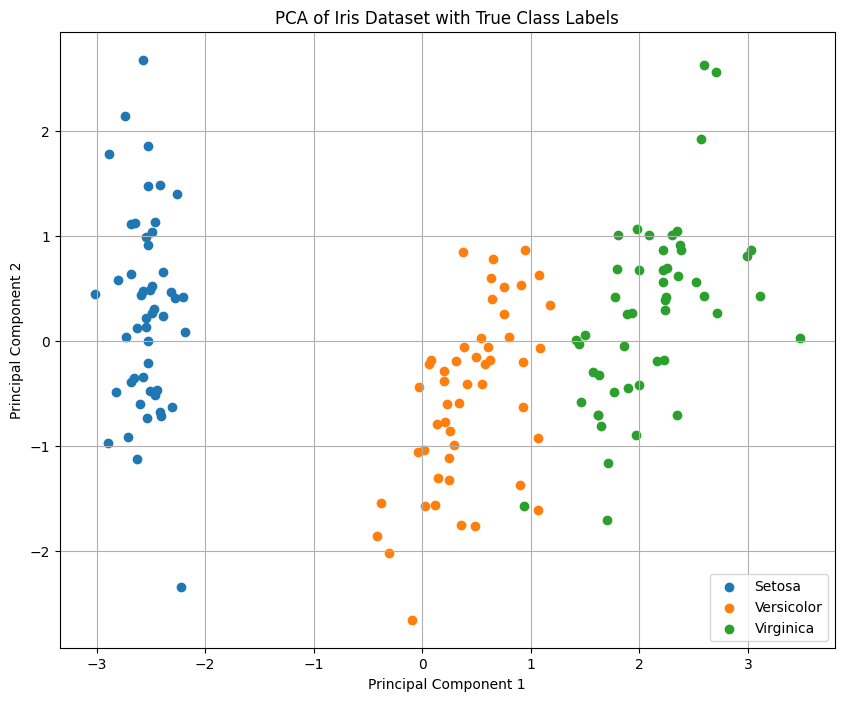

In [10]:
# Plot the PCA results with true labels
plt.figure(figsize=(10, 8))
for i, species in zip([0, 1, 2], ['Setosa', 'Versicolor', 'Virginica']):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=species)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset with True Class Labels')
plt.legend()
plt.grid(True)
plt.show()

## 4. Implement Clustering Algorithms and Evaluate

### 4.1. K-means Clustering

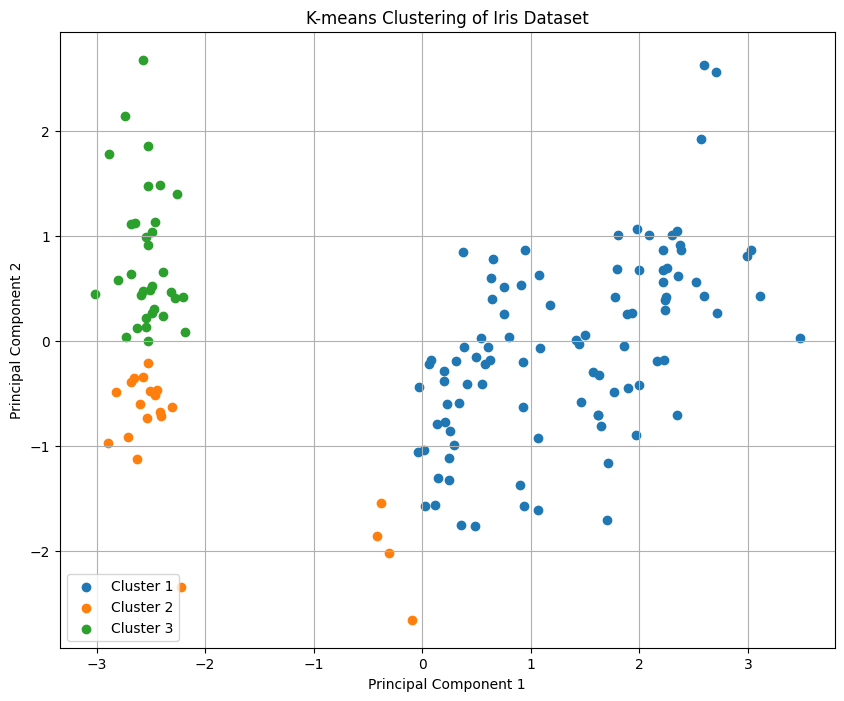

In [11]:
# K-means 
# Use KMeans from sklearn.cluster
# Test different number of clusters
# Store the predicted labels in a variable kmeans_labels

# ---------------------------
# CODE HERE
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
# ---------------------------


# Plot K-means results
n_clusters = np.unique(kmeans_labels).shape[0]
plt.figure(figsize=(10, 8))
for i in range(n_clusters):
    plt.scatter(X_pca[kmeans_labels == i, 0], X_pca[kmeans_labels == i, 1], label=f'Cluster {i+1}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-means Clustering of Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()

Evaluate K-means clustering using Silhouette Score, CHI, and DBI.

In [12]:
# Evaluate Silhouette Score
# ---------------------------
# CODE HERE
# ---------------------------
print(f"Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))

# Evaluate Calinski-Harabasz Index
# ---------------------------
# CODE HERE
# ---------------------------
print(f"Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, kmeans_labels))

# Evaluate Davies-Bouldin Index
# ---------------------------
# CODE HERE
# ---------------------------
print(f"Davies-Bouldin Index:", davies_bouldin_score(X_scaled, kmeans_labels))


Silhouette Score: 0.4726559669806779
Calinski-Harabasz Index: 164.2928888813491
Davies-Bouldin Index: 0.816350563966535


### 4.2. DBSCAN Clustering

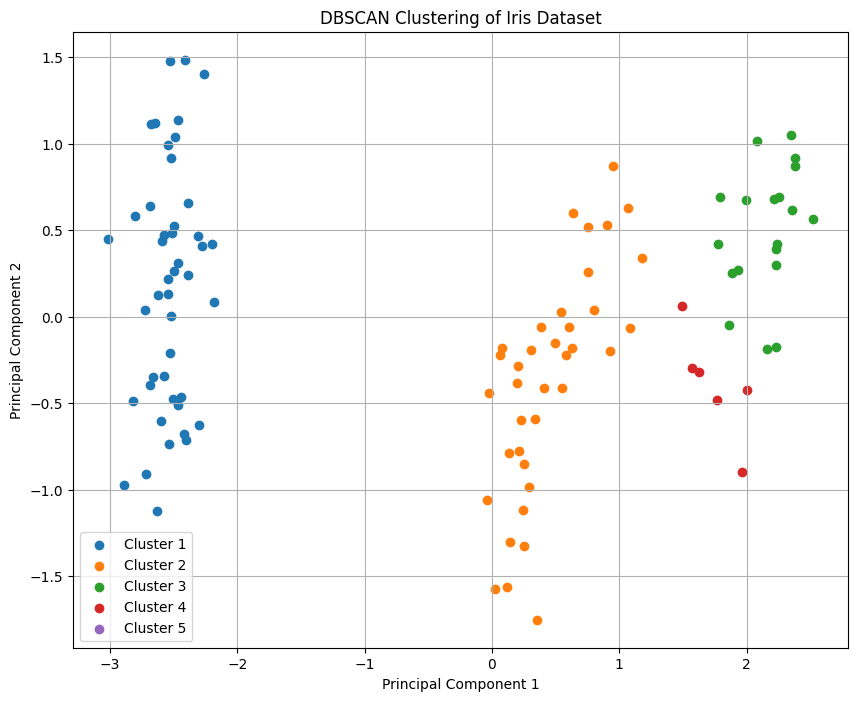

In [13]:
# DBSCAN
# Use DBSCAN from sklearn.cluster
# Test different hyperparameters
# Store the predicted labels in a variable dbscan_labels
# ---------------------------
# CODE HERE
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
# ---------------------------

# Plot DBSCAN results
n_clusters = np.unique(dbscan_labels).shape[0]
plt.figure(figsize=(10, 8))
for i in range(n_clusters):
    plt.scatter(X_pca[dbscan_labels == i, 0], X_pca[dbscan_labels == i, 1], label=f'Cluster {i+1}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering of Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()

Evaluate DBSCAN clustering using Silhouette Score, CHI, and DBI.

In [14]:
# Evaluate Silhouette Score
# ---------------------------
# CODE HERE
# ---------------------------
print(f"Silhouette Score:", silhouette_score(X_scaled, dbscan_labels))

# Evaluate Calinski-Harabasz Index
# ---------------------------
# CODE HERE
# ---------------------------
print(f"Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, dbscan_labels))

# Evaluate Davies-Bouldin Index
# ---------------------------
# CODE HERE
# ---------------------------
print(f"Davies-Bouldin Index:", davies_bouldin_score(X_scaled, dbscan_labels))


Silhouette Score: 0.22342548624684605
Calinski-Harabasz Index: 61.148090705765554
Davies-Bouldin Index: 2.5387139388163353


### 4.4. Hierarchical Clustering (Agglomerative)
First, we will use the complete linkage method to perform hierarchical clustering.
<br>Plot the dendrogram and evaluate the clustering using Silhouette Score, CHI, and DBI.

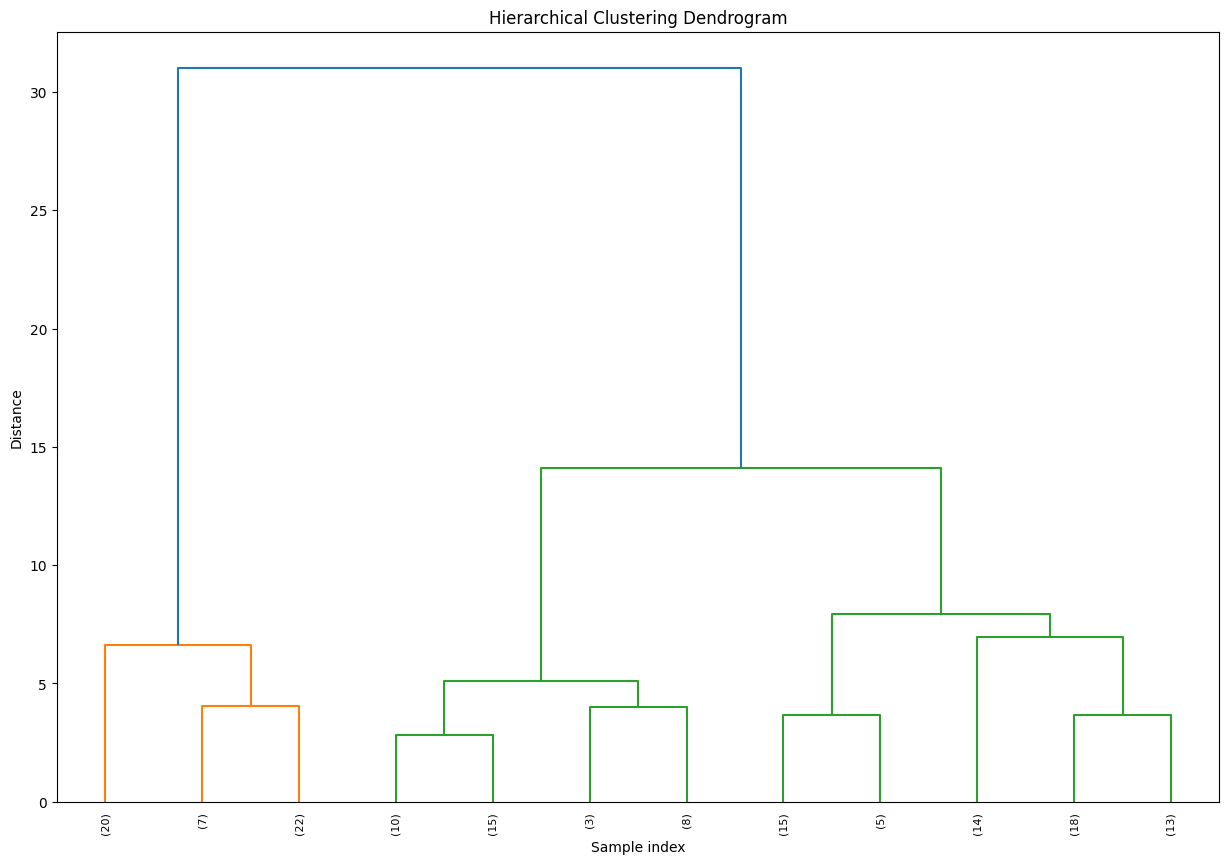

In [15]:
# Create a dendrogram to visualize the hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix using Ward's method
Z = linkage(X_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    truncate_mode='lastp',  # show only the last p clusters
    p=12  # show only the last p merged clusters
)
plt.show()

The number of clusters will be determined by the dendrogram.
The suggested number of clusters is determined by the largest vertical distance that doesn't intersect any clusters.    

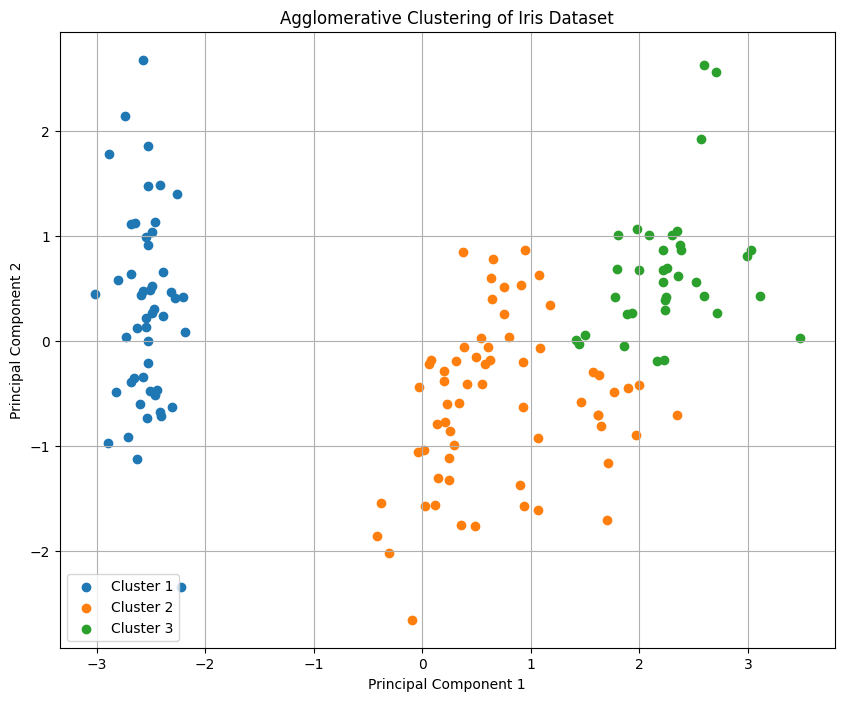

In [16]:
# Agglomerative Hierarchical Clustering 
# Use AgglomerativeClustering from sklearn.cluster
# Use the best number of clusters based on the dendrogram
# If the dendrogram is not clear, test different number of clusters
# Store the predicted labels in a variable hierarchical_labels
# ---------------------------
# CODE HERE
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='complete')
hierarchical_labels = agg_clustering.fit_predict(X_scaled)
# ---------------------------


# Plot Agglomerative results
n_clusters = np.unique(hierarchical_labels).shape[0]
plt.figure(figsize=(10, 8))
for i in range(n_clusters):
    plt.scatter(X_pca[hierarchical_labels == i, 0], X_pca[hierarchical_labels == i, 1], label=f'Cluster {i+1}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering of Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()

Evaluate the clustering using Silhouette Score, CHI, and DBI.

In [17]:
# Evaluate Silhouette Score
# ---------------------------
# CODE HERE
# ---------------------------
sil_score = silhouette_score(X_scaled, hierarchical_labels)
print(f"Silhouette Score: {sil_score:.4f}")

# Evaluate Calinski-Harabasz Index
# ---------------------------
# CODE HERE
# ---------------------------
ch_score = calinski_harabasz_score(X_scaled, hierarchical_labels)
print(f"Calinski-Harabasz Index: {ch_score:.4f}")

# Evaluate Davies-Bouldin Index
# ---------------------------
# CODE HERE
# ---------------------------
db_score = davies_bouldin_score(X_scaled, hierarchical_labels)
print(f"Davies-Bouldin Index: {db_score:.4f}")

Silhouette Score: 0.4741
Calinski-Harabasz Index: 258.5083
Davies-Bouldin Index: 0.8272


## 5. Conclusion
Answer the following questions:
- Which algorithm performed the best, and why?
- What is the optimal number of clusters for each algorithm?
- What are the advantages and disadvantages of each algorithm?
